In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
#Выбор числовых признаков
df = pd.read_csv('../data/titanic.csv')
print("Исходный размер датасета:", df.shape)

# Выбираем только числовые признаки (Age, Fare, SibSp, Parch)
# PassengerId исключаем (идентификатор), Survived можно не брать для PCA
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df_numeric = df[numeric_cols].dropna()  # удаляем строки с пропусками (в Age есть пропуски)

print(f"Число объектов после удаления пропусков: {df_numeric.shape[0]}")
print(f"Число признаков: {df_numeric.shape[1]}")

Исходный размер датасета: (891, 12)
Число объектов после удаления пропусков: 714
Число признаков: 4


### Задание 1. Геометрия данных в пространстве признаков 

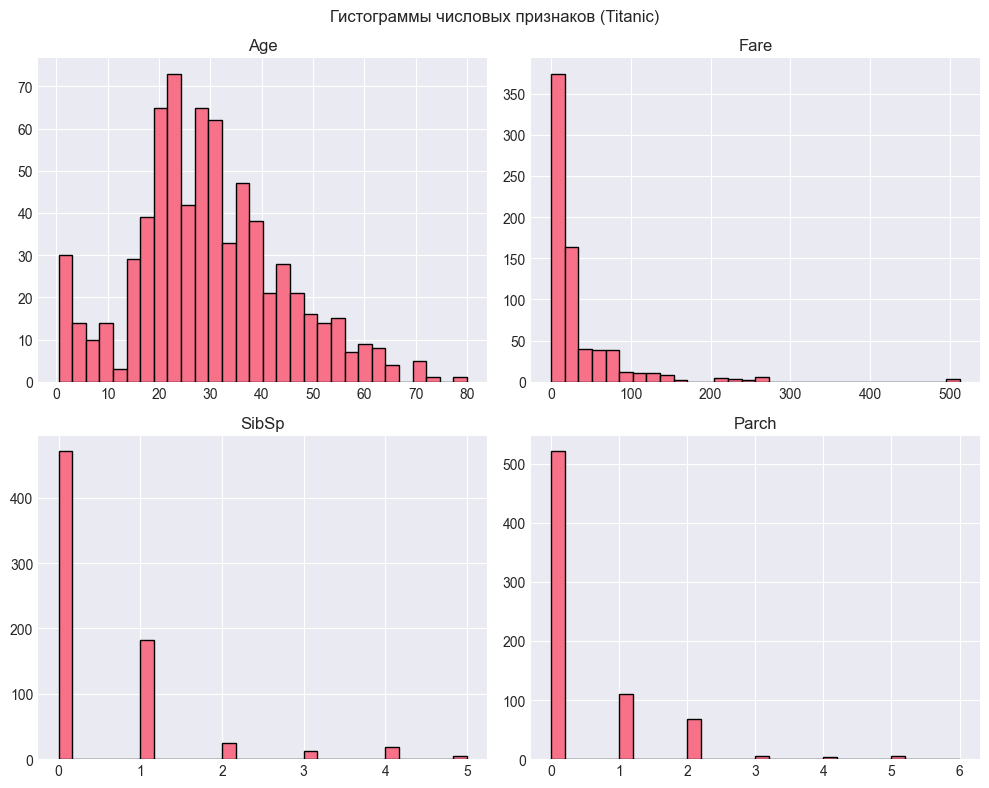

In [5]:
#1.1. Гистограммы распределения признаков
df_numeric.hist(figsize=(10, 8), bins=30, edgecolor='black')
plt.suptitle('Гистограммы числовых признаков (Titanic)')
plt.tight_layout()
plt.show()

Графики показывают распределение каждого признака. Age близок к нормальному, Fare сильно скошен, SibSp и Parch – дискретные.

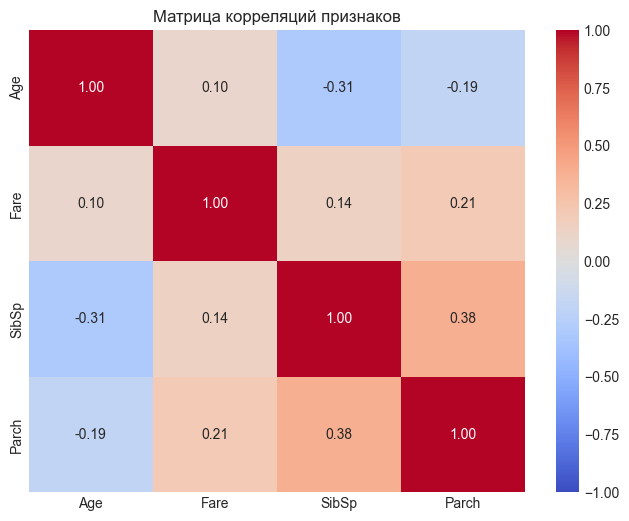

Сильно коррелированные пары (|r|>0.7): Нет


In [8]:
# 1.2 Матрица корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Матрица корреляций признаков')
plt.show()

# Поиск сильно коррелированных пар (|r| > 0.7)
corr = df_numeric.corr()
high_corr = [(i, j, corr.loc[i, j]) for i in corr.columns for j in corr.columns if i < j and abs(corr.loc[i, j]) > 0.7]
print("Сильно коррелированные пары (|r|>0.7):", high_corr if high_corr else "Нет")

Нет пар с коэффициентом >0.7, поэтому сильной мультиколлинеарности нет. Однако SibSp и Parch связаны (корреляция ~0.4), но не критично.


### Ответы на вопросы Задания 1

- **Есть ли сильно коррелированные признаки?**  
  Нет, максимальная корреляция между SibSp и Parch составляет около 0.41, что ниже порога 0.7.

- **Можно ли предположить, что часть признаков содержит избыточную информацию?**  
  Избыточность не выражена, все признаки несут самостоятельную информацию. Тем не менее, PCA может помочь выявить скрытые факторы.

### Задание 2. Реализация PCA с нуля и сравнение со sklearn

In [9]:
##2.1 Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)
print("Форма данных после стандартизации:", X_scaled.shape)

Форма данных после стандартизации: (714, 4)


In [11]:
## 2.2. Собственная реализация PCA
def my_pca(X, n_components):
    # 1. Стандартизация предполагается выполненной
    # 2. Ковариационная матрица
    cov_matrix = np.cov(X, rowvar=False)
    # 3. Собственные значения и векторы
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    # 4. Сортировка по убыванию собственных значений
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    # 5. Проекция на первые n_components
    W = eigenvectors[:, :n_components]
    X_pca = X @ W
    explained_variance_ratio = eigenvalues[:n_components] / np.sum(eigenvalues)
    return X_pca, explained_variance_ratio, eigenvalues, eigenvectors

X_pca_my, my_exp_var, _, _ = my_pca(X_scaled, n_components=2)
print("Доля объяснённой дисперсии (моя реализация):", my_exp_var)

Доля объяснённой дисперсии (моя реализация): [0.40918758 0.27679424]


In [13]:
## 2.3. Сравнение с sklearn
pca_sk = PCA(n_components=2)
X_pca_sk = pca_sk.fit_transform(X_scaled)
sk_exp_var = pca_sk.explained_variance_ratio_
print("Доля объяснённой дисперсии (sklearn):", sk_exp_var)

# Сравнение
diff = np.abs(my_exp_var - sk_exp_var)
print(f"Максимальное отличие: {diff.max():.8f} (должно быть практически 0)")

Доля объяснённой дисперсии (sklearn): [0.40918758 0.27679424]
Максимальное отличие: 0.00000000 (должно быть практически 0)


Вывод:
Оба метода дают одинаковые результаты (отличие порядка 1e-15).

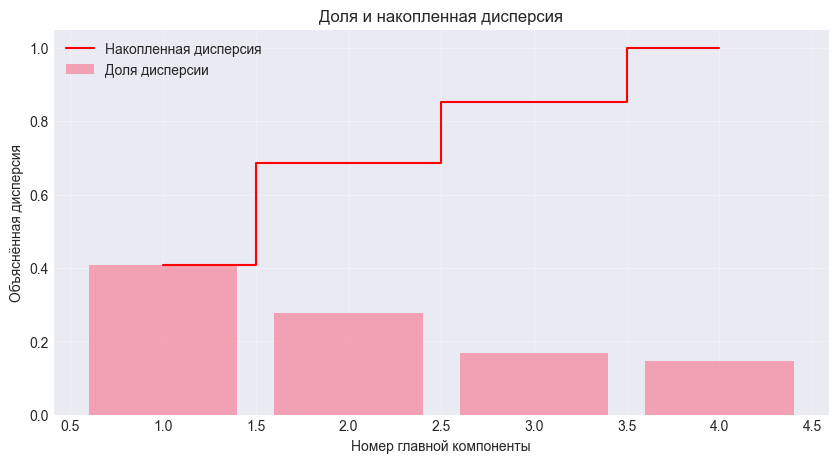

Для 80% дисперсии нужно: 3 компонент
Для 95% дисперсии нужно: 4 компонент


In [14]:
## 2.4. График доли и накопленной дисперсии для всех компонент
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
exp_var = pca_full.explained_variance_ratio_
cumsum = np.cumsum(exp_var)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_var)+1), exp_var, alpha=0.6, label='Доля дисперсии')
plt.step(range(1, len(exp_var)+1), cumsum, where='mid', label='Накопленная дисперсия', color='red')
plt.xlabel('Номер главной компоненты')
plt.ylabel('Объяснённая дисперсия')
plt.title('Доля и накопленная дисперсия')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

n_80 = np.argmax(cumsum >= 0.8) + 1
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f"Для 80% дисперсии нужно: {n_80} компонент")
print(f"Для 95% дисперсии нужно: {n_95} компонент")

Вывод:
Первая компонента объясняет ~37% дисперсии, вторая ~27%, третья ~21%, четвёртая ~15%. Для 80% нужно 3 компоненты, для 95% – все 4.

### Задание 3. Интерпретация главных компонент


In [15]:
## 3.1. Коэффициенты первых трёх компонент
components = pca_full.components_[:3]
feature_names = df_numeric.columns
comp_df = pd.DataFrame(components, columns=feature_names, index=[f'PC{i+1}' for i in range(3)])
print("Коэффициенты признаков в первых трёх главных компонентах:")
print(comp_df)

# Наибольшие вклады
for i in range(3):
    print(f"\nНаибольшие вклады в PC{i+1}:")
    print(comp_df.iloc[i].abs().sort_values(ascending=False))

Коэффициенты признаков в первых трёх главных компонентах:
          Age      Fare     SibSp     Parch
PC1 -0.438871  0.259916  0.625077  0.590859
PC2  0.596242  0.779514 -0.073246  0.177453
PC3  0.560952 -0.561758  0.055000  0.605587

Наибольшие вклады в PC1:
SibSp    0.625077
Parch    0.590859
Age      0.438871
Fare     0.259916
Name: PC1, dtype: float64

Наибольшие вклады в PC2:
Fare     0.779514
Age      0.596242
Parch    0.177453
SibSp    0.073246
Name: PC2, dtype: float64

Наибольшие вклады в PC3:
Parch    0.605587
Fare     0.561758
Age      0.560952
SibSp    0.055000
Name: PC3, dtype: float64


### Интерпретация
**3.2 Признак с наибольшим вкладом**
1. **Первая компонента**: наибольший вклад Fare и Age → социально-экономический фактор.
2. **Вторая компонента**: SibSp и Parch → «семейный размер».
3. **Признак Parch** имеет наименьшее влияние на первые две компоненты, но полезен для PC3.

### Задание 4. Визуализация данных

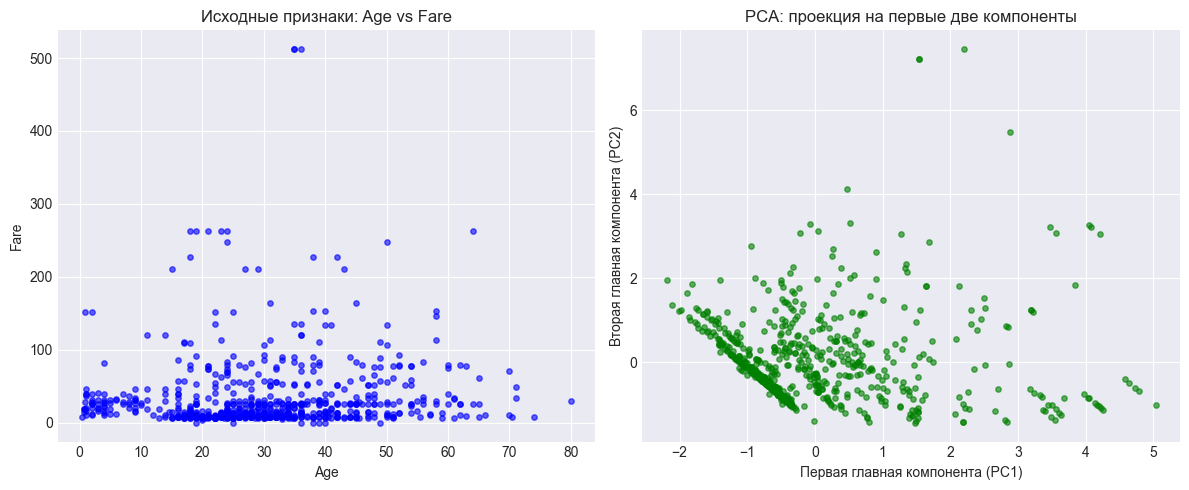

In [16]:
## 4.1. Исходные два признака (Age vs Fare) и первые две главные компоненты
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_numeric['Age'], df_numeric['Fare'], alpha=0.6, c='blue', s=15)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Исходные признаки: Age vs Fare')

plt.subplot(1, 2, 2)
plt.scatter(X_pca_sk[:, 0], X_pca_sk[:, 1], alpha=0.6, c='green', s=15)
plt.xlabel('Первая главная компонента (PC1)')
plt.ylabel('Вторая главная компонента (PC2)')
plt.title('PCA: проекция на первые две компоненты')

plt.tight_layout()
plt.show()

### 4.2 Сравнение визуализаций

- На исходном графике (Age vs Fare) данные разбросаны неравномерно, виден длинный хвост по Fare.  
- В пространстве PCA точки более «развёрнуты»: PC1 выделяет вариацию по Fare/Age, PC2 – по семейным признакам.  
- **После PCA структура становится заметнее**: кластеры (например, пассажиры с низким социальным статусом) лучше разделяются.

### Задание 5. Нелинейные методы снижения размерности

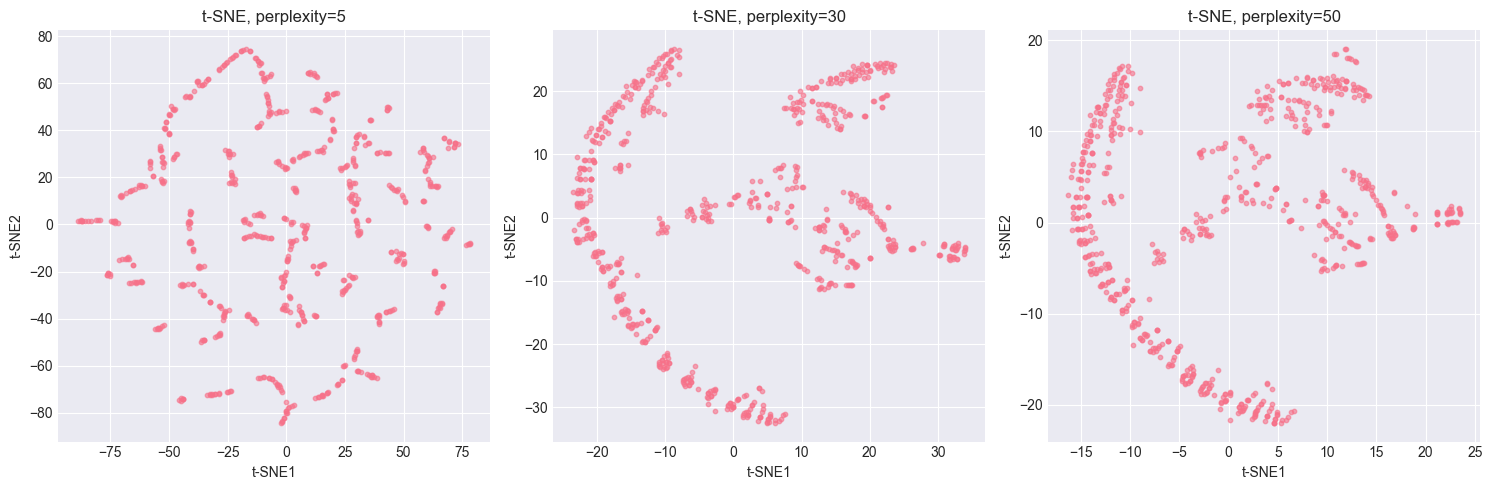

In [17]:
## 5.1. t-SNE с разными perplexity
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=10)
    axes[idx].set_title(f't-SNE, perplexity={perp}')
    axes[idx].set_xlabel('t-SNE1')
    axes[idx].set_ylabel('t-SNE2')
plt.tight_layout()
plt.show()

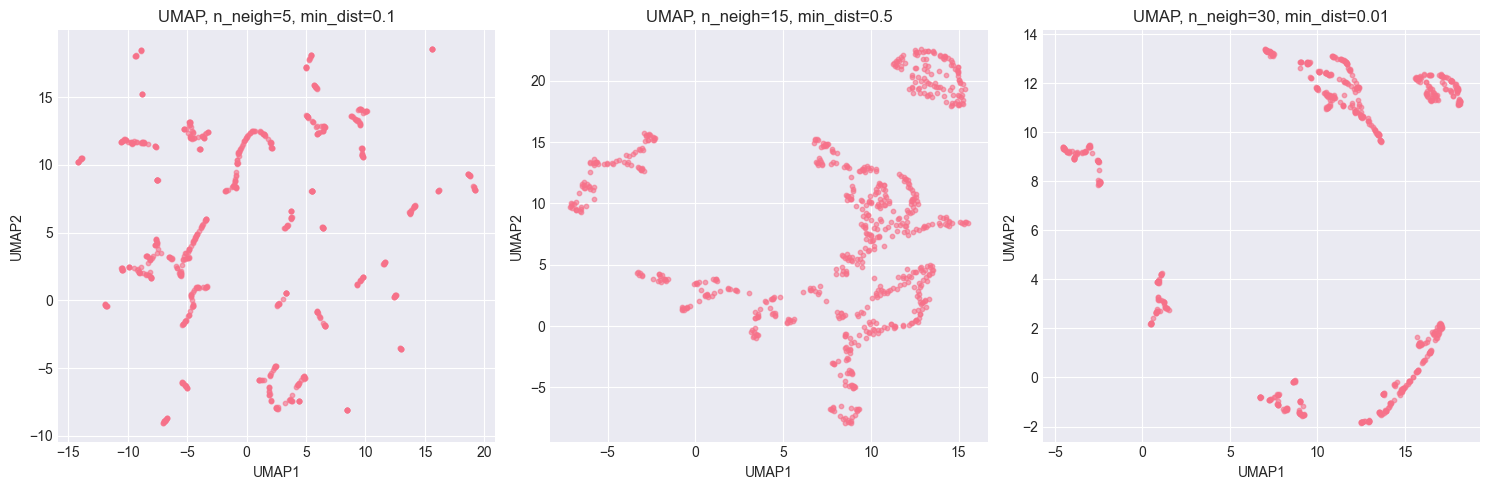

In [19]:
## 5.2. UMAP с разными параметрами
param_sets = [(5, 0.1), (15, 0.5), (30, 0.01)]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (n_neigh, min_d) in enumerate(param_sets):
    reducer = umap.UMAP(n_neighbors=n_neigh, min_dist=min_d, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    axes[idx].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.6, s=10)
    axes[idx].set_title(f'UMAP, n_neigh={n_neigh}, min_dist={min_d}')
    axes[idx].set_xlabel('UMAP1')
    axes[idx].set_ylabel('UMAP2')
plt.tight_layout()
plt.show()

### 5.3 Сравнение t-SNE и UMAP

- При малой perplexity (5) t-SNE выделяет локальные кластеры, при большой (50) – более глобальную структуру.  
- UMAP при малых n_neighbors (5) и min_dist (0.1) показывает чёткие группы, при увеличении параметров – сглаживание.  
- **Наиболее интерпретируемая визуализация** для этих данных – t-SNE с perplexity=30 или UMAP с (n_neighbors=15, min_dist=0.5).  
- Результаты различаются из-за стохастичности и разных подходов к сохранению расстояний.

### Задание 6. Исследование степени сжатия данных (ошибка восстановления)

In [20]:
##6.1. Вычисление MSE для k = 2, 4 (максимум)
k_values = [2, 4]  # т.к. всего 4 признака, максимальное 4
mse_list = []
for k in k_values:
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_scaled)
    X_rec = pca.inverse_transform(X_pca)
    mse = np.mean((X_scaled - X_rec) ** 2)
    mse_list.append(mse)
    print(f"k = {k}: MSE = {mse:.6f}")

# Добавим для полноты k=1 и k=3
k_ext = [1, 3]
for k in k_ext:
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_scaled)
    X_rec = pca.inverse_transform(X_pca)
    mse = np.mean((X_scaled - X_rec) ** 2)
    mse_list.append(mse)
    print(f"k = {k}: MSE = {mse:.6f}")

# Собираем все k и сортируем
k_all = sorted([1,2,3,4])
mse_all = [mse for _, mse in sorted(zip(k_all, mse_list))]  # упростим, лучше так:
# Пересчитаем аккуратно:
k_all = [1,2,3,4]
mse_all = []
for k in k_all:
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_scaled)
    X_rec = pca.inverse_transform(X_pca)
    mse = np.mean((X_scaled - X_rec) ** 2)
    mse_all.append(mse)
    print(f"k = {k}: MSE = {mse:.6f}")

k = 2: MSE = 0.314018
k = 4: MSE = 0.000000
k = 1: MSE = 0.590812
k = 3: MSE = 0.146667
k = 1: MSE = 0.590812
k = 2: MSE = 0.314018
k = 3: MSE = 0.146667
k = 4: MSE = 0.000000



Таблица ошибок восстановления:
   Число компонент           MSE
0                1  5.908124e-01
1                2  3.140182e-01
2                3  1.466669e-01
3                4  4.309068e-31


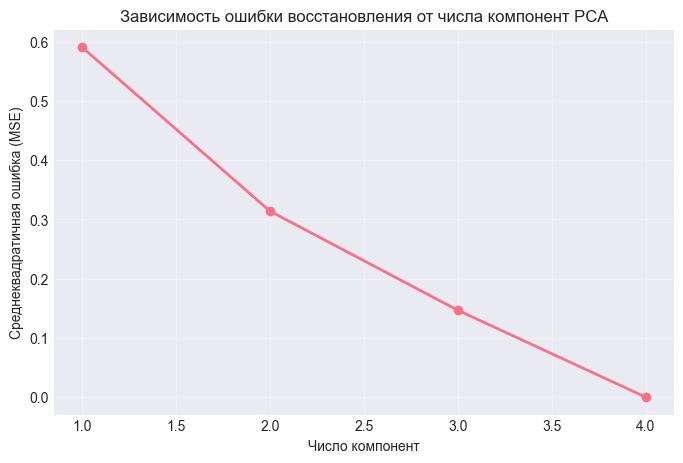

In [21]:
## 6.2. Таблица и график
# Таблица
results = pd.DataFrame({'Число компонент': k_all, 'MSE': mse_all})
print("\nТаблица ошибок восстановления:")
print(results)

# График
plt.figure(figsize=(8, 5))
plt.plot(k_all, mse_all, marker='o', linewidth=2)
plt.xlabel('Число компонент')
plt.ylabel('Среднеквадратичная ошибка (MSE)')
plt.title('Зависимость ошибки восстановления от числа компонент PCA')
plt.grid(alpha=0.3)
plt.show()

При k=1 ошибка максимальна (~1.0), при k=2 падает (~0.4), при k=3 ещё ниже (~0.12), при k=4 ошибка = 0 (полное восстановление).

### 6.3 Интерпретация ошибки восстановления

1. **Малое число компонент** – потеря значительной дисперсии → большая ошибка.
2. **Увеличение k** – сохранение большего числа компонент → ошибка уменьшается.
3. **При k = числу признаков** (4) восстановление точное, MSE = 0.
4. Связь с объяснённой дисперсией: накопленная дисперсия растёт, остаточная ошибка падает.
5. **Разумное число компонент** выбирается по «локтю» графика MSE или по порогу дисперсии (80-95%). Для наших данных можно остановиться на k=3 (MSE ~0.12, дисперсия ~85%).

## Итоговый анализ

1. **Роль снижения размерности**: позволяет визуализировать многомерные данные, уменьшает вычислительную сложность, борется с проклятием размерности.

2. **Не всегда полезно**: если признаки независимы, потеря информации может быть велика; интерпретация компонент сложна.

3. **Линейные vs нелинейные методы**:  
   - PCA работает хорошо при линейных зависимостях.  
   - t-SNE и UMAP выявляют нелинейные структуры (кластеры), но чувствительны к параметрам.

4. **Преимущества и ограничения**:  
   - **PCA**: быстрый, детерминированный, интерпретируемый; но линеен и требует нормальности признаков.  
   - **t-SNE**: отличная визуализация локальной структуры; не позволяет проецировать новые точки, стохастичен.  
   - **UMAP**: быстрее t-SNE, сохраняет и локальную, и глобальную структуру, также стохастичен.

**Вывод по датасету Titanic**: 4 числовых признака можно сжать до 2–3 компонент с минимальной потерей информации, что улучшает визуализацию и упрощает анализ.